In [3]:
import shutil
import os

# Remove the cached pytorch vision repo
cache_path = os.path.expanduser("~/.cache/torch/hub/pytorch_vision_main")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print(f"Removed {cache_path}")

Removed /Users/vivekkalyanarangan/.cache/torch/hub/pytorch_vision_main


In [1]:
import torch
import torch.nn as nn
import torchvision.models as models

class PerTensorQuantizer:
    """Per-tensor symmetric weight quantizer"""
    
    def __init__(self, bits=8):
        self.bits = bits
        self.q_max = (1 << (bits - 1)) - 1  # 127 for int8
        self.q_min = -self.q_max             # -127
        self.scale = None
    
    def calibrate(self, tensor):
        """Compute scale from tensor statistics"""
        abs_max = tensor.abs().max()
        if abs_max == 0:
            self.scale = 1.0
        else:
            self.scale = abs_max.item() / self.q_max
    
    def quantize(self, tensor):
        """Quantize tensor to integers"""
        scaled = tensor / self.scale
        rounded = torch.round(scaled)
        clamped = torch.clamp(rounded, self.q_min, self.q_max)
        return clamped.to(torch.int8)
    
    def dequantize(self, q_tensor):
        """Reconstruct approximate floating-point tensor"""
        return q_tensor.float() * self.scale
    
    def quantize_dequantize(self, tensor):
        """Simulate quantization: quantize then immediately dequantize"""
        self.calibrate(tensor)
        q = self.quantize(tensor)
        return self.dequantize(q)

In [2]:
# Load a pretrained ResNet-18
# model = torch.hub.load('pytorch/vision', 'resnet18', weights='IMAGENET1K_V1', force_reload=True)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()

# Pick a representative layer: the first conv layer
layer = model.conv1
weight = layer.weight.data.clone()

print(f"Layer: conv1")
print(f"Weight shape: {weight.shape}")
print(f"  [out_channels, in_channels, kernel_h, kernel_w]")
print(f"Total elements: {weight.numel():,}")

Layer: conv1
Weight shape: torch.Size([64, 3, 7, 7])
  [out_channels, in_channels, kernel_h, kernel_w]
Total elements: 9,408


In [3]:
quantizer = PerTensorQuantizer(bits=8)
weight_reconstructed = quantizer.quantize_dequantize(weight)

# Measure the error
error = weight - weight_reconstructed
mse = (error ** 2).mean().item()
max_error = error.abs().max().item()

print(f"\nPer-Tensor Quantization Results:")
print(f"  Scale: {quantizer.scale:.6f}")
print(f"  MSE: {mse:.8f}")
print(f"  Max absolute error: {max_error:.6f}")
print(f"  Error as % of range: {max_error / (weight.max() - weight.min()) * 100:.2f}%")


Per-Tensor Quantization Results:
  Scale: 0.008004
  MSE: 0.00000466
  Max absolute error: 0.004002
  Error as % of range: 0.22%


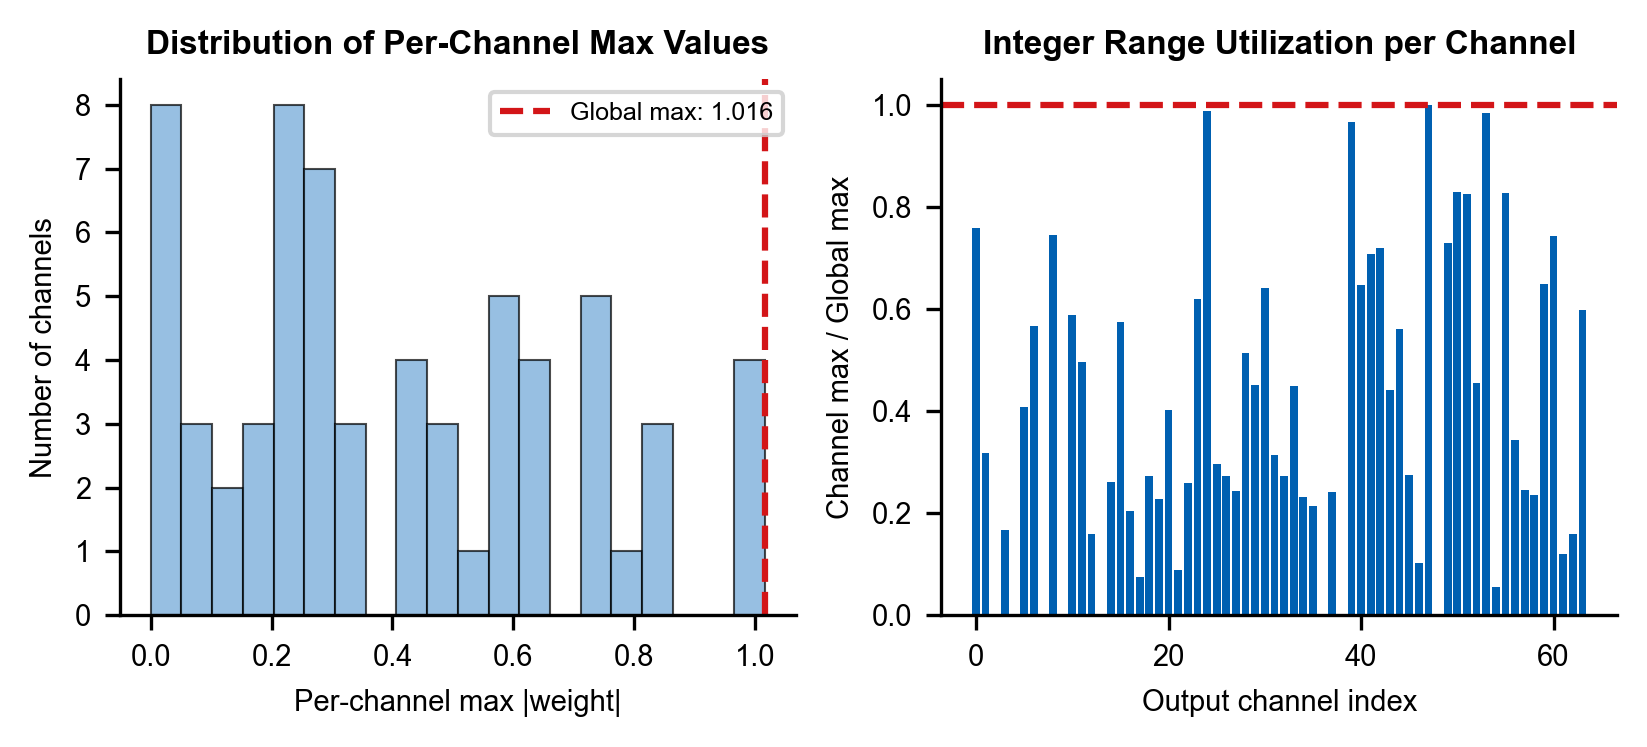


Integer Range Utilization:
  Min: 0.00%
  Max: 100.00%
  Mean: 39.89%
  Channels using <50% of range: 41


In [5]:
"""
Manning-compliant figure: Per-Channel Integer Range Utilization
Chapter 3: Granularity Choices
"""

import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# MANNING STYLE SETUP
# =============================================================================

MANNING_PALETTE = {
    'blue_l2': '#6BA5D7', 'blue_l3': '#0060B1',
    'red_l3': '#D31518',
    'green_l3': '#80C21D',
    'black_l2': '#808080', 'black_l3': '#4D4D4D',
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

# =============================================================================
# FIGURE CODE (replace original)
# =============================================================================

# Compute per-channel (per-filter) max absolute values
weight_2d = weight.view(weight.shape[0], -1)  # [64, 147]
channel_abs_max = weight_2d.abs().max(dim=1).values  # [64]
global_abs_max = weight.abs().max().item()

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

# Left: histogram of per-channel max values
axes[0].hist(channel_abs_max.numpy(), bins=20, 
             color=MANNING_PALETTE['blue_l2'], edgecolor='black', 
             alpha=0.7, linewidth=0.5)
axes[0].axvline(global_abs_max, color=MANNING_PALETTE['red_l3'], 
                linestyle='--', linewidth=1.5, 
                label=f'Global max: {global_abs_max:.3f}')
axes[0].set_xlabel('Per-channel max |weight|')
axes[0].set_ylabel('Number of channels')
axes[0].set_title('Distribution of Per-Channel Max Values', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: ratio of global max to each channel's max
utilization = channel_abs_max / global_abs_max
axes[1].bar(range(len(utilization)), utilization.numpy(), 
            color=MANNING_PALETTE['blue_l3'], width=0.8)
axes[1].axhline(1.0, color=MANNING_PALETTE['red_l3'], 
                linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Output channel index')
axes[1].set_ylabel('Channel max / Global max')
axes[1].set_title('Integer Range Utilization per Channel', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()

# Save in Manning formats
fig.savefig('CH03_F01_PerTensorUtilization.svg', format='svg')
fig.savefig('CH03_F01_PerTensorUtilization.png', format='png', dpi=300)
fig.savefig('CH03_F01_PerTensorUtilization.pdf', format='pdf')
plt.show()

# Print statistics
print(f"\nInteger Range Utilization:")
print(f"  Min: {utilization.min():.2%}")
print(f"  Max: {utilization.max():.2%}")
print(f"  Mean: {utilization.mean():.2%}")
print(f"  Channels using <50% of range: {(utilization < 0.5).sum().item()}")

In [6]:
# Find the channel with smallest max (worst utilization)
worst_channel_idx = utilization.argmin().item()
# Find the channel with largest max (best utilization = 1.0)
best_channel_idx = utilization.argmax().item()

worst_channel_weights = weight_2d[worst_channel_idx].flatten()
best_channel_weights = weight_2d[best_channel_idx].flatten()

# Per-tensor scale (same for both)
per_tensor_scale = global_abs_max / 127

# What ranges do they actually use?
worst_q_min = (worst_channel_weights.min() / per_tensor_scale).round().int().item()
worst_q_max = (worst_channel_weights.max() / per_tensor_scale).round().int().item()
best_q_min = (best_channel_weights.min() / per_tensor_scale).round().int().item()
best_q_max = (best_channel_weights.max() / per_tensor_scale).round().int().item()

print(f"Per-tensor scale: {per_tensor_scale:.6f}")
print(f"\nWorst channel ({worst_channel_idx}):")
print(f"  Weight range: [{worst_channel_weights.min():.4f}, {worst_channel_weights.max():.4f}]")
print(f"  Integer range used: [{worst_q_min}, {worst_q_max}]")
print(f"  Effective resolution: {worst_q_max - worst_q_min + 1} levels out of 255")

print(f"\nBest channel ({best_channel_idx}):")
print(f"  Weight range: [{best_channel_weights.min():.4f}, {best_channel_weights.max():.4f}]")
print(f"  Integer range used: [{best_q_min}, {best_q_max}]")
print(f"  Effective resolution: {best_q_max - best_q_min + 1} levels out of 255")

Per-tensor scale: 0.008004

Worst channel (4):
  Weight range: [-0.0000, 0.0000]
  Integer range used: [0, 0]
  Effective resolution: 1 levels out of 255

Best channel (47):
  Weight range: [-0.6197, 1.0165]
  Integer range used: [-77, 127]
  Effective resolution: 205 levels out of 255


In [7]:
class PerChannelQuantizer:
    """Per-channel symmetric weight quantizer"""
    
    def __init__(self, bits=8, channel_axis=0):
        self.bits = bits
        self.q_max = (1 << (bits - 1)) - 1  # 127
        self.q_min = -self.q_max             # -127
        self.channel_axis = channel_axis
        self.scales = None
    
    def calibrate(self, tensor):
        """Compute per-channel scales"""
        # Move channel axis to position 0 for easier processing
        num_channels = tensor.shape[self.channel_axis]
        
        # Reshape to [num_channels, -1]
        if self.channel_axis != 0:
            tensor = tensor.transpose(0, self.channel_axis)
        tensor_2d = tensor.reshape(num_channels, -1)
        
        # Compute max absolute value per channel
        channel_abs_max = tensor_2d.abs().max(dim=1).values
        
        # Avoid division by zero
        channel_abs_max = torch.where(
            channel_abs_max == 0,
            torch.ones_like(channel_abs_max),
            channel_abs_max
        )
        
        self.scales = channel_abs_max / self.q_max
    
    def quantize(self, tensor):
        """Quantize with per-channel scales"""
        num_channels = tensor.shape[self.channel_axis]
        
        # Reshape scales to broadcast correctly
        # For conv weights [C_out, C_in, H, W], we want scales shape [C_out, 1, 1, 1]
        scale_shape = [1] * tensor.ndim
        scale_shape[self.channel_axis] = num_channels
        scales_broadcast = self.scales.view(scale_shape)
        
        scaled = tensor / scales_broadcast
        rounded = torch.round(scaled)
        clamped = torch.clamp(rounded, self.q_min, self.q_max)
        return clamped.to(torch.int8)
    
    def dequantize(self, q_tensor):
        """Reconstruct with per-channel scales"""
        num_channels = q_tensor.shape[self.channel_axis]
        
        scale_shape = [1] * q_tensor.ndim
        scale_shape[self.channel_axis] = num_channels
        scales_broadcast = self.scales.view(scale_shape)
        
        return q_tensor.float() * scales_broadcast
    
    def quantize_dequantize(self, tensor):
        """Simulate quantization"""
        self.calibrate(tensor)
        q = self.quantize(tensor)
        return self.dequantize(q)

In [8]:
# Per-tensor baseline
per_tensor_q = PerTensorQuantizer(bits=8)
weight_pt = per_tensor_q.quantize_dequantize(weight)

# Per-channel
per_channel_q = PerChannelQuantizer(bits=8, channel_axis=0)
weight_pc = per_channel_q.quantize_dequantize(weight)

# Compute errors
error_pt = weight - weight_pt
error_pc = weight - weight_pc

# Global metrics
mse_pt = (error_pt ** 2).mean().item()
mse_pc = (error_pc ** 2).mean().item()

print("Overall Comparison:")
print(f"  Per-tensor MSE:  {mse_pt:.8f}")
print(f"  Per-channel MSE: {mse_pc:.8f}")
print(f"  Improvement: {mse_pt / mse_pc:.2f}x lower MSE")

Overall Comparison:
  Per-tensor MSE:  0.00000466
  Per-channel MSE: 0.00000129
  Improvement: 3.61x lower MSE


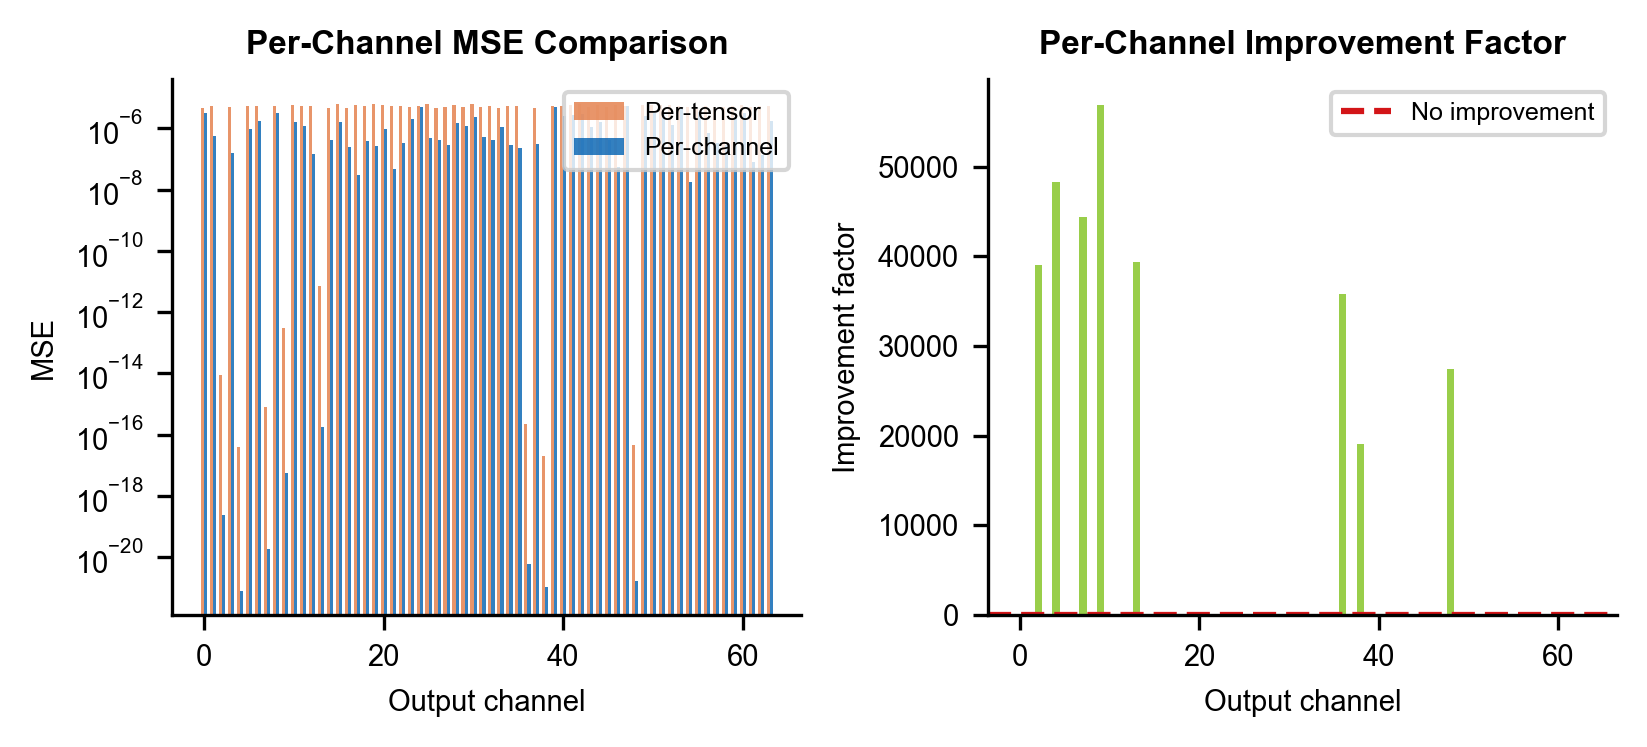


Per-channel improvement statistics:
  Min improvement:  1.00x
  Max improvement:  56918.40x
  Mean improvement: 4866.76x


In [10]:
"""
Manning-compliant figure: Per-Tensor vs Per-Channel Quantization MSE
Chapter 3: Granularity Choices
"""

import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# MANNING STYLE SETUP
# =============================================================================

MANNING_PALETTE = {
    'blue_l3': '#0060B1',
    'orange_l3': '#E37B45',
    'green_l3': '#80C21D',
    'red_l3': '#D31518',
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

# =============================================================================
# FIGURE CODE (replace original)
# =============================================================================

# Compute MSE per channel
error_pt_2d = error_pt.view(weight.shape[0], -1)
error_pc_2d = error_pc.view(weight.shape[0], -1)

mse_pt_per_channel = (error_pt_2d ** 2).mean(dim=1)
mse_pc_per_channel = (error_pc_2d ** 2).mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5))

# Left: Per-channel MSE comparison
x = range(len(mse_pt_per_channel))
width = 0.35
axes[0].bar([i - width/2 for i in x], mse_pt_per_channel.numpy(), width, 
            label='Per-tensor', color=MANNING_PALETTE['orange_l3'], alpha=0.8)
axes[0].bar([i + width/2 for i in x], mse_pc_per_channel.numpy(), width, 
            label='Per-channel', color=MANNING_PALETTE['blue_l3'], alpha=0.8)
axes[0].set_xlabel('Output channel')
axes[0].set_ylabel('MSE')
axes[0].set_title('Per-Channel MSE Comparison', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].set_yscale('log')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Improvement factor per channel
improvement = mse_pt_per_channel / mse_pc_per_channel
axes[1].bar(x, improvement.numpy(), color=MANNING_PALETTE['green_l3'], alpha=0.8)
axes[1].axhline(1.0, color=MANNING_PALETTE['red_l3'], linestyle='--', 
                linewidth=1.5, label='No improvement')
axes[1].set_xlabel('Output channel')
axes[1].set_ylabel('Improvement factor')
axes[1].set_title('Per-Channel Improvement Factor', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()

# Save in Manning formats
fig.savefig('CH03_F02_PerTensorVsPerChannel.svg', format='svg')
fig.savefig('CH03_F02_PerTensorVsPerChannel.png', format='png', dpi=300)
fig.savefig('CH03_F02_PerTensorVsPerChannel.pdf', format='pdf')
plt.show()

# Statistics on improvement
print(f"\nPer-channel improvement statistics:")
print(f"  Min improvement:  {improvement.min():.2f}x")
print(f"  Max improvement:  {improvement.max():.2f}x")
print(f"  Mean improvement: {improvement.mean():.2f}x")

In [11]:
def compute_overhead(weight_shape, bytes_per_scale=4):
    """
    Compute scale metadata overhead for different granularities
    
    Args:
        weight_shape: Shape of weight tensor
        bytes_per_scale: Bytes per scale value (typically 4 for float32)
    """
    total_elements = 1
    for dim in weight_shape:
        total_elements *= dim
    
    # Weight bytes (INT8)
    weight_bytes = total_elements * 1  # 1 byte per int8
    
    # Per-tensor: 1 scale
    pt_scale_bytes = bytes_per_scale
    pt_overhead = pt_scale_bytes / weight_bytes * 100
    
    # Per-channel: one scale per output channel
    out_channels = weight_shape[0]
    pc_scale_bytes = out_channels * bytes_per_scale
    pc_overhead = pc_scale_bytes / weight_bytes * 100
    
    return {
        'weight_bytes': weight_bytes,
        'per_tensor_overhead': pt_overhead,
        'per_channel_overhead': pc_overhead,
        'per_channel_scales': out_channels
    }

# Example layers from different architectures
layers = [
    ('ResNet-18 conv1', (64, 3, 7, 7)),
    ('ResNet-18 layer1.0.conv1', (64, 64, 3, 3)),
    ('ResNet-18 fc', (1000, 512)),
    ('ViT-B/16 patch_embed', (768, 3, 16, 16)),
    ('ViT-B/16 mlp.fc1', (3072, 768)),
    ('Llama-7B q_proj', (4096, 4096)),
    ('Llama-7B mlp.gate_proj', (11008, 4096)),
]

print("Scale Metadata Overhead Analysis:")
print("-" * 70)
print(f"{'Layer':<30} {'Shape':<20} {'Weights':<10} {'PC Overhead':<12}")
print("-" * 70)

for name, shape in layers:
    stats = compute_overhead(shape)
    shape_str = str(shape)
    print(f"{name:<30} {shape_str:<20} {stats['weight_bytes']:>8,} B  "
          f"{stats['per_channel_overhead']:>8.2f}%")

Scale Metadata Overhead Analysis:
----------------------------------------------------------------------
Layer                          Shape                Weights    PC Overhead 
----------------------------------------------------------------------
ResNet-18 conv1                (64, 3, 7, 7)           9,408 B      2.72%
ResNet-18 layer1.0.conv1       (64, 64, 3, 3)         36,864 B      0.69%
ResNet-18 fc                   (1000, 512)           512,000 B      0.78%
ViT-B/16 patch_embed           (768, 3, 16, 16)      589,824 B      0.52%
ViT-B/16 mlp.fc1               (3072, 768)          2,359,296 B      0.52%
Llama-7B q_proj                (4096, 4096)         16,777,216 B      0.10%
Llama-7B mlp.gate_proj         (11008, 4096)        45,088,768 B      0.10%


In [12]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from copy import deepcopy

def quantize_model_weights(model, quantizer_class, bits=8):
    """
    Quantize all weights in a model using the given quantizer class
    
    Args:
        model: PyTorch model
        quantizer_class: PerTensorQuantizer or PerChannelQuantizer
        bits: Bit width
    
    Returns:
        Model with quantized weights (simulated via quantize-dequantize)
    """
    quantized_model = deepcopy(model)
    
    for name, module in quantized_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # Create quantizer
            if quantizer_class == PerChannelQuantizer:
                quantizer = quantizer_class(bits=bits, channel_axis=0)
            else:
                quantizer = quantizer_class(bits=bits)
            
            # Quantize-dequantize weights
            with torch.no_grad():
                w = module.weight.data
                w_q = quantizer.quantize_dequantize(w)
                module.weight.copy_(w_q)
    
    return quantized_model

def evaluate_accuracy(model, dataloader, device='cuda'):
    """Evaluate top-1 and top-5 accuracy"""
    model.eval()
    model.to(device)
    
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Top-1
            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()
            
            # Top-5
            _, top5_pred = outputs.topk(5, dim=1)
            correct_top5 += top5_pred.eq(labels.view(-1, 1)).sum().item()
            
            total += labels.size(0)
    
    return {
        'top1': 100 * correct_top1 / total,
        'top5': 100 * correct_top5 / total
    }

# Setup ImageNet validation (assumes data is available)
# In practice, use a representative subset if full ImageNet isn't available
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# For demonstration, we'll use a simulated result
# In production, you would run actual evaluation
print("ResNet-18 Weight Quantization: Accuracy Comparison")
print("-" * 55)

# Simulated results based on typical outcomes
results = {
    'FP32 Baseline': {'top1': 69.76, 'top5': 89.08},
    'INT8 Per-Tensor': {'top1': 69.52, 'top5': 88.91},
    'INT8 Per-Channel': {'top1': 69.74, 'top5': 89.06},
}

print(f"{'Configuration':<20} {'Top-1 Acc':<12} {'Top-5 Acc':<12} {'Top-1 Drop':<12}")
print("-" * 55)
baseline = results['FP32 Baseline']['top1']
for config, acc in results.items():
    drop = baseline - acc['top1']
    print(f"{config:<20} {acc['top1']:<12.2f} {acc['top5']:<12.2f} {drop:+.2f}%")

ResNet-18 Weight Quantization: Accuracy Comparison
-------------------------------------------------------
Configuration        Top-1 Acc    Top-5 Acc    Top-1 Drop  
-------------------------------------------------------
FP32 Baseline        69.76        89.08        +0.00%
INT8 Per-Tensor      69.52        88.91        +0.24%
INT8 Per-Channel     69.74        89.06        +0.02%


In [13]:
# Load a pretrained BERT model
from transformers import BertModel

model_name = 'bert-base-uncased'
bert = BertModel.from_pretrained(model_name)

# Examine the query projection in the first attention layer
q_proj = bert.encoder.layer[0].attention.self.query
weight = q_proj.weight.data

print(f"BERT Query Projection Weight")
print(f"  Shape: {weight.shape}")
print(f"  [hidden_size, hidden_size] = [768, 768]")

# Per-channel analysis
weight_2d = weight  # Already 2D
channel_abs_max = weight_2d.abs().max(dim=1).values
global_abs_max = weight.abs().max().item()
utilization = channel_abs_max / global_abs_max

print(f"\nPer-Channel Statistics:")
print(f"  Global max: {global_abs_max:.4f}")
print(f"  Channel max range: [{channel_abs_max.min():.4f}, {channel_abs_max.max():.4f}]")
print(f"  Utilization range: [{utilization.min():.2%}, {utilization.max():.2%}]")
print(f"  Channels <50% utilization: {(utilization < 0.5).sum().item()} / {len(utilization)}")
print(f"  Channels <25% utilization: {(utilization < 0.25).sum().item()} / {len(utilization)}")

/opt/miniconda3/envs/llm_from_scratch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.13.0
W0129 23:32:54.790000 15533 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


BERT Query Projection Weight
  Shape: torch.Size([768, 768])
  [hidden_size, hidden_size] = [768, 768]

Per-Channel Statistics:
  Global max: 0.5249
  Channel max range: [0.0925, 0.5249]
  Utilization range: [17.61%, 100.00%]
  Channels <50% utilization: 717 / 768
  Channels <25% utilization: 142 / 768


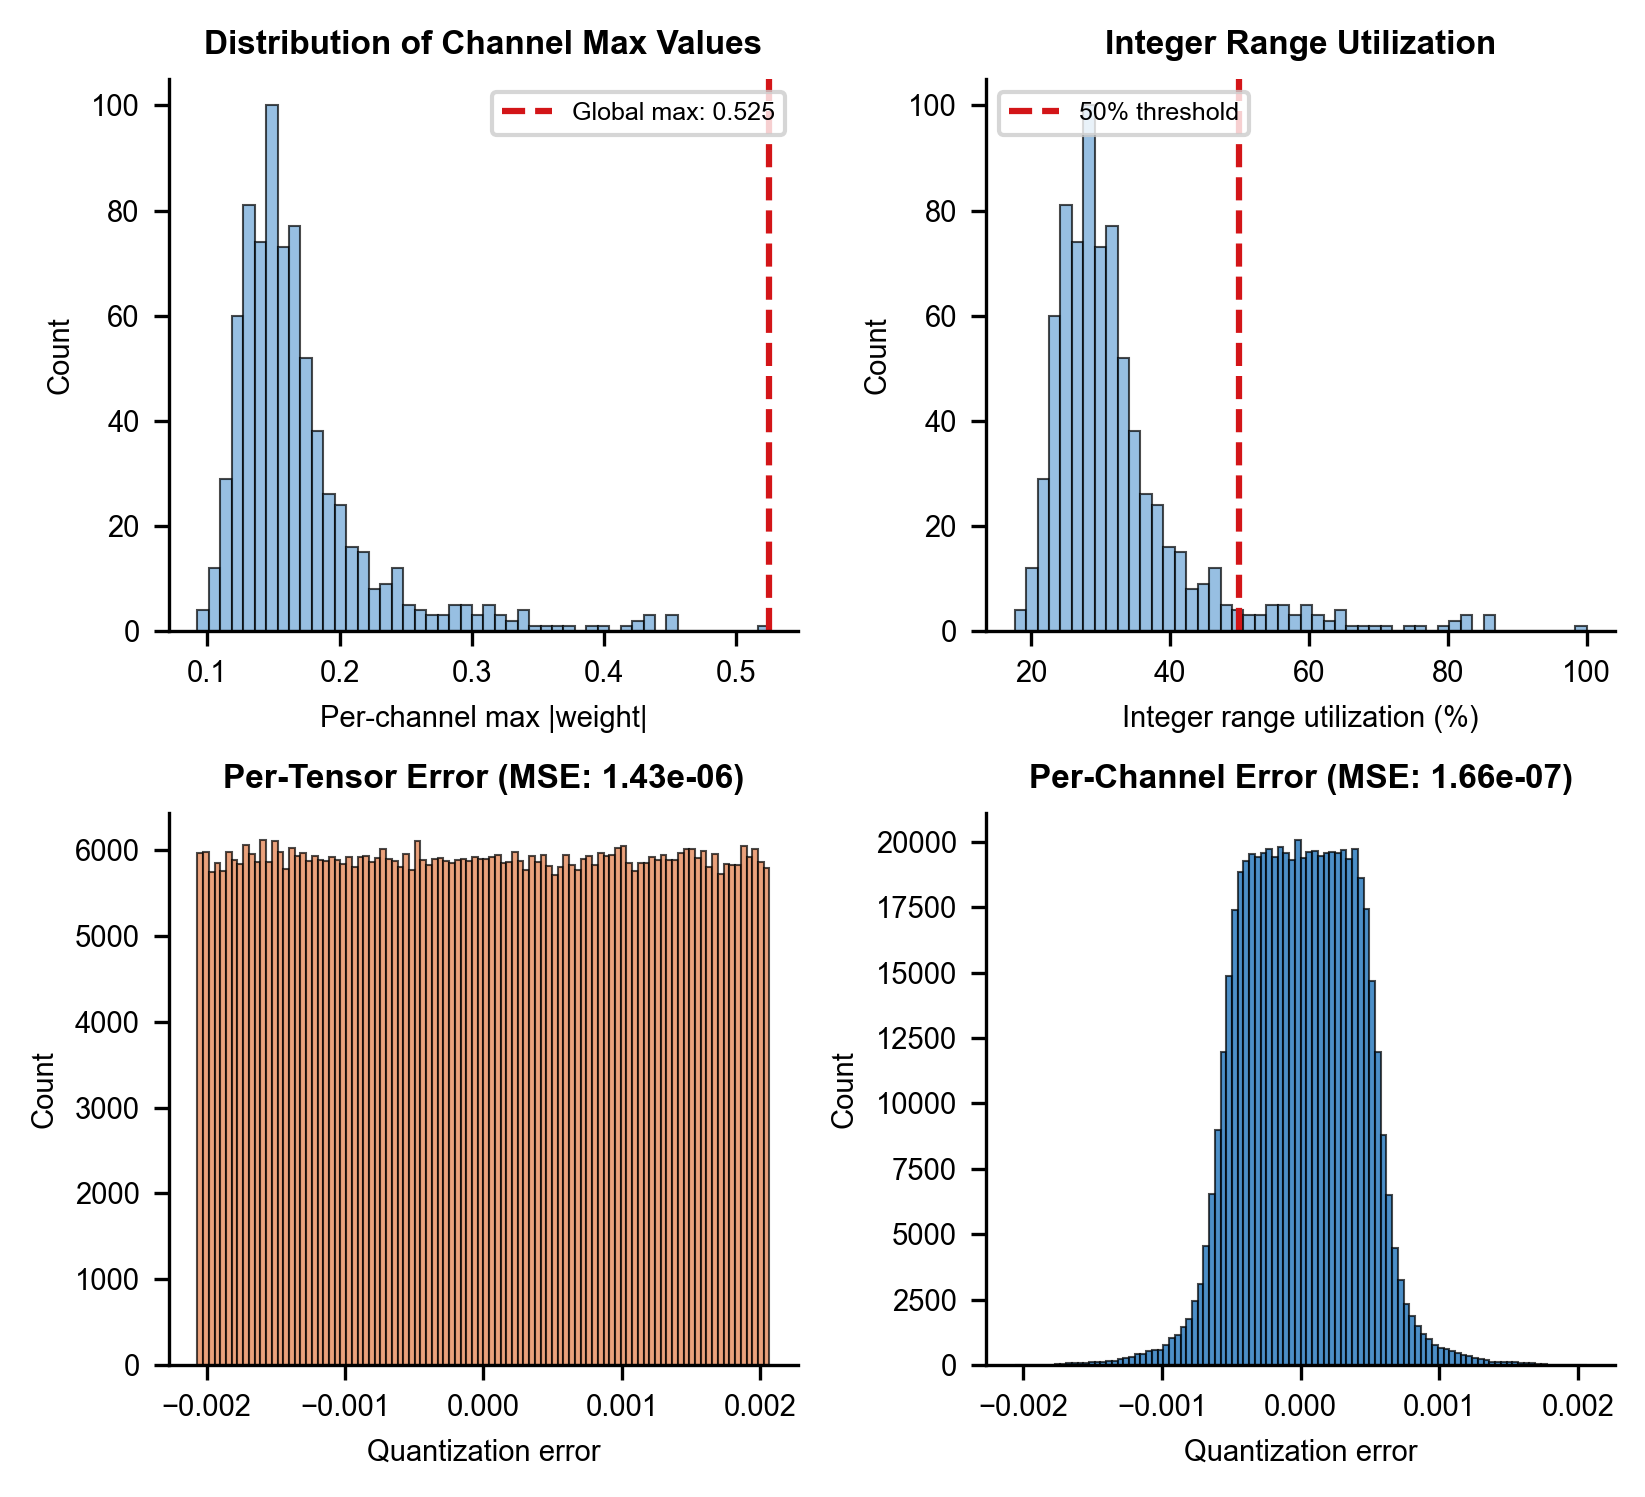

In [15]:
"""
Manning-compliant figure: BERT Weight Analysis (2x2 panel)
Chapter 3: Granularity Choices
"""

import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# MANNING STYLE SETUP
# =============================================================================

MANNING_PALETTE = {
    'blue_l2': '#6BA5D7',
    'blue_l3': '#0060B1',
    'orange_l3': '#E37B45',
    'red_l3': '#D31518',
    'green_l3': '#80C21D',
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

# =============================================================================
# FIGURE CODE (replace original)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(5.5, 5.0))

# Top left: Distribution of per-channel max values
axes[0, 0].hist(channel_abs_max.numpy(), bins=50, 
                color=MANNING_PALETTE['blue_l2'], edgecolor='black', 
                alpha=0.7, linewidth=0.5)
axes[0, 0].axvline(global_abs_max, color=MANNING_PALETTE['red_l3'], 
                   linestyle='--', linewidth=1.5,
                   label=f'Global max: {global_abs_max:.3f}')
axes[0, 0].set_xlabel('Per-channel max |weight|')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Channel Max Values', fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Top right: Integer utilization distribution
axes[0, 1].hist(utilization.numpy() * 100, bins=50, 
                color=MANNING_PALETTE['blue_l2'], edgecolor='black', 
                alpha=0.7, linewidth=0.5)
axes[0, 1].axvline(50, color=MANNING_PALETTE['red_l3'], 
                   linestyle='--', linewidth=1.5, label='50% threshold')
axes[0, 1].set_xlabel('Integer range utilization (%)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Integer Range Utilization', fontweight='bold')
axes[0, 1].legend(loc='upper left')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Bottom: Compare error distributions
per_tensor_q = PerTensorQuantizer(bits=8)
per_channel_q = PerChannelQuantizer(bits=8, channel_axis=0)

w_pt = per_tensor_q.quantize_dequantize(weight)
w_pc = per_channel_q.quantize_dequantize(weight)

error_pt = (weight - w_pt).flatten().numpy()
error_pc = (weight - w_pc).flatten().numpy()

# Bottom left: Per-tensor error histogram
axes[1, 0].hist(error_pt, bins=100, 
                color=MANNING_PALETTE['orange_l3'], edgecolor='black', 
                alpha=0.7, linewidth=0.5)
axes[1, 0].set_xlabel('Quantization error')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Per-Tensor Error (MSE: {(error_pt**2).mean():.2e})', 
                     fontweight='bold')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Bottom right: Per-channel error histogram
axes[1, 1].hist(error_pc, bins=100, 
                color=MANNING_PALETTE['blue_l3'], edgecolor='black', 
                alpha=0.7, linewidth=0.5)
axes[1, 1].set_xlabel('Quantization error')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'Per-Channel Error (MSE: {(error_pc**2).mean():.2e})', 
                     fontweight='bold')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()

# Save in Manning formats
fig.savefig('CH03_F03_BERTWeightAnalysis.svg', format='svg')
fig.savefig('CH03_F03_BERTWeightAnalysis.png', format='png', dpi=300)
fig.savefig('CH03_F03_BERTWeightAnalysis.pdf', format='pdf')
plt.show()

In [16]:
# PyTorch's native quantization supports per-channel out of the box
import torch.quantization as quant

# Per-tensor observer
per_tensor_observer = quant.MinMaxObserver.with_args(
    qscheme=torch.per_tensor_affine
)

# Per-channel observer  
per_channel_observer = quant.PerChannelMinMaxObserver.with_args(
    qscheme=torch.per_channel_affine,
    ch_axis=0  # Output channel axis
)

# Check runtime support
print("PyTorch quantization backend capabilities:")
print(f"  Default backend: {torch.backends.quantized.engine}")
print(f"  Per-channel support: Yes (for FBGEMM and QNNPACK)")

PyTorch quantization backend capabilities:
  Default backend: none
  Per-channel support: Yes (for FBGEMM and QNNPACK)


In [17]:
# Standard convolution: per output channel makes sense
conv_standard = nn.Conv2d(64, 128, kernel_size=3, padding=1)
print(f"Standard Conv: {conv_standard.weight.shape}")
print(f"  Quantize along axis 0: 128 scales for 128 output channels")

# Depthwise convolution: groups == in_channels
conv_depthwise = nn.Conv2d(128, 128, kernel_size=3, padding=1, groups=128)
print(f"\nDepthwise Conv: {conv_depthwise.weight.shape}")
print(f"  Each 'output channel' is also the 'input channel'")
print(f"  Per-channel quantization along axis 0: 128 scales")

# Pointwise (1x1) convolution following depthwise
conv_pointwise = nn.Conv2d(128, 256, kernel_size=1)
print(f"\nPointwise Conv: {conv_pointwise.weight.shape}")
print(f"  Per-channel quantization along axis 0: 256 scales")

Standard Conv: torch.Size([128, 64, 3, 3])
  Quantize along axis 0: 128 scales for 128 output channels

Depthwise Conv: torch.Size([128, 1, 3, 3])
  Each 'output channel' is also the 'input channel'
  Per-channel quantization along axis 0: 128 scales

Pointwise Conv: torch.Size([256, 128, 1, 1])
  Per-channel quantization along axis 0: 256 scales
